### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 10</center>
---

### Overview

The main objective of this exercise is to study lowpass filters in the frequency domain and their application. For this purpose, three types of lowpass filters are considered: the ideal lowpass filter (ILPF), the Butterworth lowpass filter (BLPF), and the Gaussian lowpass filter (GLPF).

In the frequency domain, the filters are typically constructed so that they are centered at $(M/2, N/2$), if the filter size is $M\times N$ (typically identical to the size of the image to be filtered). The distance to the center can be computed as follows:

$$D(u, v) = \sqrt{(u-M/2)^2 + (v-N/2)^2}$$

The following figure shows the transfer functions of the filters and their shapes:
<br />
<center><img src="images/lowpass-filters.png"  width="800px" /></center>

All transfer functions are real and symmetric (zero-phase-shift filters) so that the IDFT should be real as well. In practice, the IDFT often has very small imaginary parts due to rounding errors and other computational inaccuracies. It is therefore common to work with the real part of the IDFT only.

The centered spatial representation of such filters can be computed in different ways, as exemplarily shown for an ILPF (in this exercise, the first variant is used):
<br />
<center><img src="images/idft-filters.png"  width="600px" /></center>

Filtering in the frequency domain is performed by an elementwise multiplication of the filter transfer function $H(u,v)$ and the centered Fourier transform $F(u,v)$ of the image to be filtered. For this purpose, the Numpy function <a href="https://numpy.org/doc/stable/reference/generated/numpy.multiply.html">`multiply` ↗</a> can be used.

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

In [2]:
# based on the log transformation from task sheet 3
def log_transformation(img):
    # create empty image
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    for row in range(rows):
        for col in range(cols):
            c = 255 / np.log(1 + np.amax(img)) # normalize result to 255*[0,1]
            res[row, col] = c * np.log(1 + img[row, col]) # min of log = 0, max = np.log(1 + img[i, j])
            
    # return result
    return res

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.1</span> Notch Filter

The notch filter is a basic filter and forces the average value of an image to zero. This can be achieved by setting the Fourier transform $F(u,v)$ of an image $f(x,y)$ to zero at $F(0,0)$ or $F(M/2, N/2)$, depending on whether the Fourier transform has been centered or not. In other words, the Fourier transform at these positions is the mean value of the image. In terms of a transfer function, the notch filter can be expressed as follows:

$$
H(u,v) =
\begin{cases}
0 & \text{if }(u,v) = 0\text{ or }(u,v)=(M/2, N/2)\\
1 & \text{otherwise}
\end{cases}
$$

Implement / solve the following tasks:
    
1. Compute the DFT of the image *p-building-small.png*.
2. Apply the notch filter (set the mean value of the image to zero).
3. Compute the corresponding IDFT and plot the result.

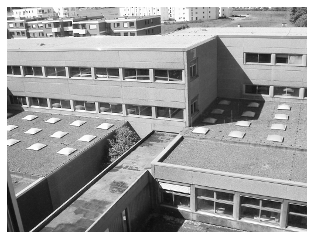

In [3]:
# write your code here
img = cv2.imread('images/p-building-small.png', 0)
plot_img_orig(img)

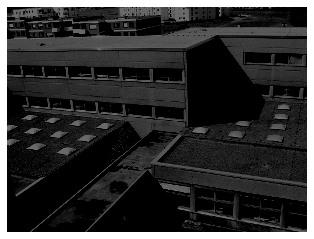

In [4]:
img_dft = np.fft.fft2(img)
img_dft[0,0] = 0

img_idft = np.fft.ifft2(img_dft)
img_back = np.real(img_idft)

plot_img_orig(img_back)

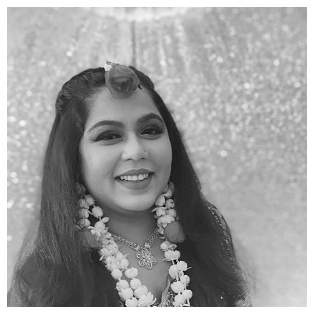

In [5]:
imgr = cv2.imread('images/raida.png', 0)
plot_img_orig(imgr)

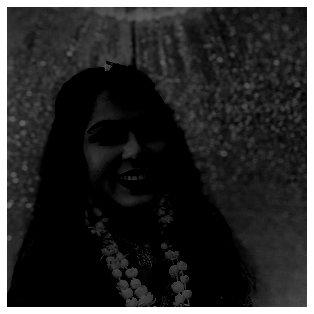

In [6]:
imgr_dft = np.fft.fft2(imgr)
imgr_dft[0, 0] = 0
imgr_idft = np.fft.ifft2(imgr_dft)
imgr_back = np.real(imgr_idft)
plot_img_orig(imgr_back)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.2</span> Ideal Lowpass Filter

Implement / solve the following tasks:
    
1. Write a function to create a $M\times N$ ideal lowpass filter with given cutoff frequency $D_0$.
2. Create $200 \times 200$ lowpass filters with $D_0 = 10, 20, 30$, respectively, and plot them (multiply by $255$ for this).
3. Write a function to multiply a transfer function by $(-1)^{(u+v)}$ or an image by $(-1)^{(x+y)}$.
4. Write a function to compute the centered spatial representation $h(x,y)$ of a given transfer function $H(u,v)$.
5. Compute and plot the (normalized) spatial representations of the filters from the second subtask and compare the results.

In [7]:
# write your code here

# compute transfer function of ideal lowpass filter (ILPF) with cutoff frequency (radius) d0
def tf_ilpf(rows, cols, d0):
    # create empty image
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    cm = int(rows/2)
    cn = int(cols/2)

    for row_u in range(rows):
        for col_v in range(cols):
            d = np.sqrt((row_u - cm)**2 + (col_v - cn)**2)
            if d <= d0:
                res[row_u, col_v] = 1
            
    # return result
    return res

In [8]:
def center(img):
    """multiply given image by (-1)^(x+y), made to work for both SD and FD images """
    
    # create empty image
    rows, cols = img.shape 
    res = np.zeros(shape=[rows, cols], dtype=np.float64) 
    
    for row in range(rows):
        for col in range(cols):
            res[row, col] = img[row, col] * (-1) ** (row + col)
    
    # return result
    return res

In [9]:
# compute centered spatial representation h(x,y) of a given transfer function H(u,v)
def spatial_repr(img):
    # create empty image
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros
    
    res = center(img)

    res = np.fft.ifft2(res)
    res_re = np.real(res)
    res = center(res_re)
    
    # return result
    return res

In [10]:
ilpf1 = tf_ilpf(200, 200, 10) 
cv2.imwrite("output/ilpf1.png", 255*ilpf1)

ilpf2 = tf_ilpf(200, 200, 20) 
cv2.imwrite("output/ilpf2.png", 255*ilpf2)

ilpf3 = tf_ilpf(200, 200, 30) 
cv2.imwrite("output/ilpf3.png", 255*ilpf3)

True

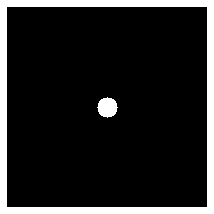

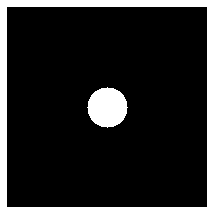

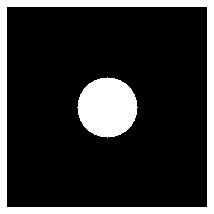

In [11]:
plot_img_orig(cv2.imread('output/ilpf1.png', 0))
plot_img_orig(cv2.imread('output/ilpf2.png', 0))
plot_img_orig(cv2.imread('output/ilpf3.png', 0))

In [12]:
ilpf1_spatial = spatial_repr(ilpf1)
ilpf2_spatial = spatial_repr(ilpf2)
ilpf3_spatial = spatial_repr(ilpf3)

In [13]:
ilpf1_spatial_n = cv2.normalize(ilpf1_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/ilpf1_spatial_n.png", ilpf1_spatial_n)

ilpf2_spatial_n = cv2.normalize(ilpf2_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/ilpf2_spatial_n.png", ilpf2_spatial_n)

ilpf3_spatial_n = cv2.normalize(ilpf3_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/ilpf3_spatial_n.png", ilpf3_spatial_n)

True

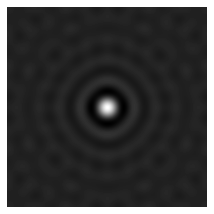

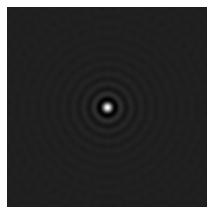

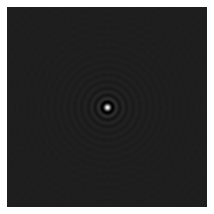

In [14]:
plot_img_orig(cv2.imread('output/ilpf1_spatial_n.png', 0))
plot_img_orig(cv2.imread('output/ilpf2_spatial_n.png', 0))
plot_img_orig(cv2.imread('output/ilpf3_spatial_n.png', 0))

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.3</span> Butterworth Lowpass Filter

Implement / solve the following tasks:
    
1. Write a function to create a $M\times N$ Butterworth lowpass filter with given cutoff frequency $D_0$ and order $n$.
2. Create $200 \times 200$ Butterworth lowpass filters with $D_0 = 10, 20, 30$ and $n=2, 10$, respectively, and plot them (multiply by $255$ for this).
3. Compute and plot the (normalized) spatial representations of the filters from the second subtask and compare the results.

In [15]:
# write your code here

# compute transfer function of Butterworth lowpass filter (BLPF) w/ cutoff frequency d0 and order n
def tf_blpf(rows, cols, d0, n):
    # create empty image
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    cm = int(rows/2)
    cn = int(cols/2)

    for row_u in range(rows):
        for col_v in range(cols):
            d = np.sqrt((row_u - cm)**2 + (col_v - cn)**2)
            res[row_u, col_v] = 1 / (1+(d/d0)**(2*n))

    # return result
    return res

In [16]:
blpf1 = tf_blpf(200, 200, 10, 2) 
cv2.imwrite("output/blpf1.png", 255*blpf1)

blpf2 = tf_blpf(200, 200, 20, 2) 
cv2.imwrite("output/blpf2.png", 255*blpf2)

blpf3 = tf_blpf(200, 200, 30, 2) 
cv2.imwrite("output/blpf3.png", 255*blpf3)

True

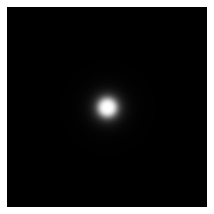

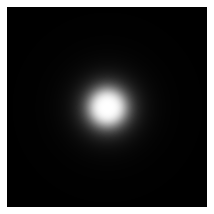

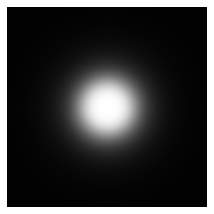

In [17]:
plot_img_orig(cv2.imread('output/blpf1.png', 0))
plot_img_orig(cv2.imread('output/blpf2.png', 0))
plot_img_orig(cv2.imread('output/blpf3.png', 0))

In [18]:
blpf4 = tf_blpf(200, 200, 10, 10) 
cv2.imwrite("output/blpf4.png", 255*blpf4)

blpf5 = tf_blpf(200, 200, 20, 10)
cv2.imwrite("output/blpf5.png", 255*blpf5)

blpf6 = tf_blpf(200, 200, 30, 10)
cv2.imwrite("output/blpf6.png", 255*blpf6)

True

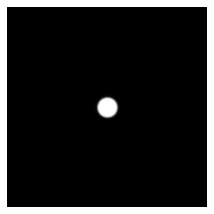

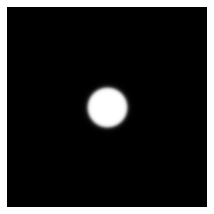

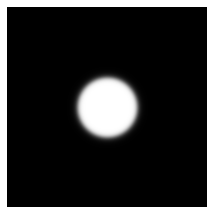

In [19]:
plot_img_orig(cv2.imread('output/blpf4.png', 0))
plot_img_orig(cv2.imread('output/blpf5.png', 0))
plot_img_orig(cv2.imread('output/blpf6.png', 0))

In [20]:
blpf1_spatial = spatial_repr(blpf1)
blpf2_spatial = spatial_repr(blpf2)
blpf3_spatial = spatial_repr(blpf3)


In [21]:
blpf4_spatial = spatial_repr(blpf4)
blpf5_spatial = spatial_repr(blpf5)
blpf6_spatial = spatial_repr(blpf6)

In [22]:
blpf1_spatial_n = cv2.normalize(blpf1_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf1_spatial_n.png", blpf1_spatial_n)

blpf2_spatial_n = cv2.normalize(blpf2_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf2_spatial_n.png", blpf2_spatial_n)

blpf3_spatial_n = cv2.normalize(blpf3_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf3_spatial_n.png", blpf3_spatial_n)

True

In [23]:
blpf4_spatial_n = cv2.normalize(blpf4_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf4_spatial_n.png", blpf4_spatial_n)

blpf5_spatial_n = cv2.normalize(blpf5_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf5_spatial_n.png", blpf5_spatial_n)

blpf6_spatial_n = cv2.normalize(blpf6_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf6_spatial_n.png", blpf6_spatial_n)

True

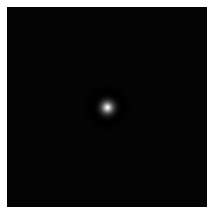

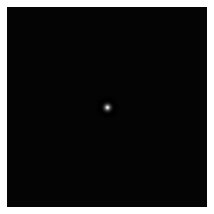

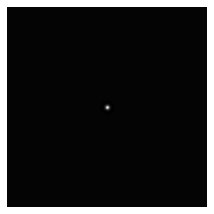

In [24]:
plot_img_orig(cv2.imread('output/blpf1_spatial_n.png', 0))
plot_img_orig(cv2.imread('output/blpf2_spatial_n.png', 0))
plot_img_orig(cv2.imread('output/blpf3_spatial_n.png', 0))

In the frequency domain, the transfer functions are much smoother than the transfer functions of the ILPF. The cutoff frequency is controlled by $D_0$, while the level of smoothness is controlled by the order $n$. The larger the order, the sharper the transition and the more ringing. This can clearly be seen for $n=10$, for which the transfer function already approaches an ILPF. Therefore, $n=2$ is often a good choice in practice.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.4</span> Gaussian Lowpass Filter

Implement / solve the following tasks:
    
1. Write a function to create a $M\times N$ Gaussian lowpass filter with given cutoff frequency $D_0$ ($=\sigma$).
2. Create $200 \times 200$ Gaussian lowpass filters with $D_0 = 10, 20, 30$, respectively, and plot them (multiply by $255$ for this).
3. Compute and plot the (normalized) spatial representations of the filters from the second subtask and compare the results.

In [33]:
# write your code here

# compute transfer function of Butterworth lowpass filter (BLPF) w/ cutoff frequency d0 and order n
def tf_glpf(rows, cols, d0):
    # create empty image
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    cm = int(rows/2)
    cn = int(cols/2)

    for row_u in range(rows):
        for col_v in range(cols):
            d = np.sqrt((row_u-cm)**2 + (col_v-cn)**2)
            res[row_u, col_v] = np.exp(-(d**2/(2*d0**2)))

    # return result
    return res

In [34]:
glpf1 = tf_glpf(200, 200, 10)
cv2.imwrite("output/glpf1.png", 255*glpf1)

glpf2 = tf_glpf(200, 200, 20) 
cv2.imwrite("output/glpf2.png", 255*glpf2)

glpf3 = tf_glpf(200, 200, 30) 
cv2.imwrite("output/glpf3.png", 255*glpf3)

True

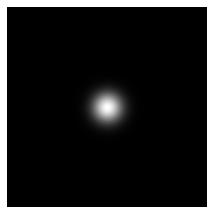

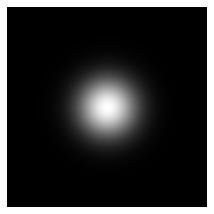

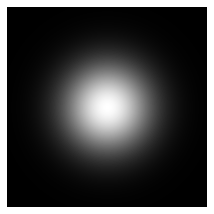

In [35]:
plot_img_orig(cv2.imread('output/glpf1.png', 0))
plot_img_orig(cv2.imread('output/glpf2.png', 0))
plot_img_orig(cv2.imread('output/glpf3.png', 0))

In [36]:
glpf1_spatial = spatial_repr(glpf1)
glpf2_spatial = spatial_repr(glpf2)
glpf3_spatial = spatial_repr(glpf3)

In [37]:
glpf1_spatial_n = cv2.normalize(glpf1_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/glpf1_spatial_n.png", glpf1_spatial_n)

glpf2_spatial_n = cv2.normalize(glpf2_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/glpf2_spatial_n.png", glpf2_spatial_n)

glpf3_spatial_n = cv2.normalize(glpf3_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/glpf3_spatial_n.png", glpf3_spatial_n)

True

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.5</span> Padding and Cropping

Filtering in the frequency domain is performed by an elementwise multiplication of the filter transfer function $H(u,v)$ and the centered Fourier transform $F(u,v)$ of the image to be filtered. In the spatial domain, the multiplication corresponds to a circular convolution (DFT automatically implies periodicity so that the multiplication corresponds to a convolution of periodic functions in the spatial domain, see lecture notes for details). This leads to a wraparound error, which can be avoided by zero padding the input images of the circular convolution. If the images have the same size $M\times N$, then the new size (after padding) can be selected as $2M \times 2N$, where the input image is aligned at the top left.

Implement / solve the following tasks:
    
1. Filter the image *gray.png* in the frequency domain by an ILPF with $D_0 = 10$ without zero padding and plot the result after the IDFT.
2. Write a function to add suitable zero padding to the input image and plot the padded image.
3. Again filter the image *gray.png* and plot the result, but this time with zero padding and $D_0 = 20$. Compare the results.
4. Write a function to crop the padded result to the original image size and plot the result.

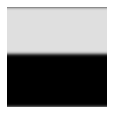

In [38]:
# write your code here
# 1.
img = cv2.imread('images/gray.png', 0)
img_dft = np.fft.fft2(img)
img_dft_shift = np.fft.fftshift(img_dft)
rows, cols = img.shape
glpf = tf_glpf(rows, cols, 10)
img_filtered = np.multiply(img_dft_shift, glpf)
img_filtered_backshift = np.fft.ifftshift(img_filtered)
img_idft = np.fft.ifft2(img_filtered_backshift)
img_idft_real = np.real(img_idft)
plot_img_orig(img_idft_real)

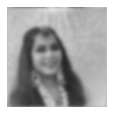

In [40]:
img = cv2.imread('images/raida-small.png', 0)
img_dft = np.fft.fft2(img)
img_dft_shift = np.fft.fftshift(img_dft)
rows, cols = img.shape
glpf = tf_glpf(rows, cols, 10)
img_filtered = np.multiply(img_dft_shift, glpf)
img_filtered_backshift = np.fft.ifftshift(img_filtered)
img_idft = np.fft.ifft2(img_filtered_backshift)
img_idft_real = np.real(img_idft)
plot_img_orig(img_idft_real)

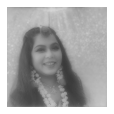

In [53]:
img = cv2.imread('images/raida-small.png', 0)
img_dft = np.fft.fft2(img)
img_dft_shift = np.fft.fftshift(img_dft)
rows, cols = img.shape
blpf = tf_blpf(rows, cols, 10, 0.5)
img_filter = np.multiply(img_dft_shift, blpf)
img_idft_shift_back = np.fft.ifftshift(img_filter)
img_idft = np.fft.ifft2(img_idft_shift_back)
img_real = np.real(img_idft)
plot_img_orig(img_real)

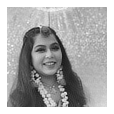

In [44]:
img = cv2.imread('images/raida-small.png', 0)
img_dft = np.fft.fft2(img)
img_dft_shift = np.fft.fftshift(img_dft)
rows, cols = img.shape
ilpf = tf_ilpf(rows, cols, 50)
img_filter = np.multiply(img_dft_shift, ilpf)
img_filter_shift_back = np.fft.ifftshift(img_filter)
img_idft = np.fft.ifft2(img_filter_shift_back)
img_real = np.real(img_idft)
plot_img_orig(img_real)


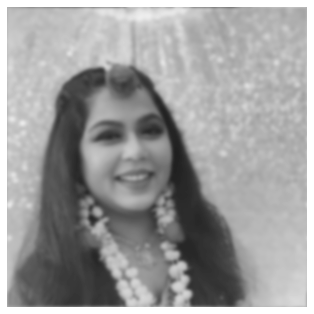

In [58]:
img = cv2.imread('images/raida.png', 0)
img_dft = np.fft.fft2(img)
img_dft_shift = np.fft.fftshift(img_dft)
rows, cols = img.shape
glpf = tf_glpf(rows, cols, 30)
img_filter = np.multiply(img_dft_shift, glpf)
img_idft_shift_back = np.fft.ifftshift(img_filter)
img_idft = np.fft.ifft2(img_idft_shift_back)
img_idft_real = np.real(img_idft)
plot_img_orig(img_idft_real)


In [59]:
# pad image with zeros
def zero_pad_img(img):
    rows, cols = img.shape
    res = cv2.copyMakeBorder(img, 0, rows, 0, cols, cv2.BORDER_CONSTANT)
    return res
    # ...

# crop image
def crop_img(img):
    rows, cols = img.shape
    cm = int(rows/2)
    cn = int(cols/2)
    res = img[0:cm, 0:cn]
    return res


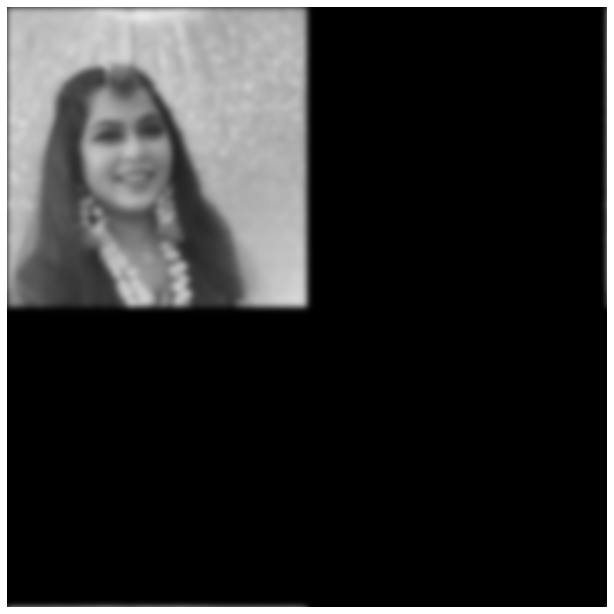

In [64]:
img = cv2.imread('images/raida.png', 0)
img = zero_pad_img(img)
img_dft = np.fft.fft2(img)
rows, cols = img.shape
glpf = tf_glpf(rows, cols, 30)
img_dft_shift = np.fft.fftshift(img_dft)
img_filter = np.multiply(img_dft_shift, glpf)
img_filter_shift = np.fft.ifftshift(img_filter)
img_idft = np.fft.ifft2(img_filter_shift)
img_idft_real = np.real(img_idft)
plot_img_orig(img_idft_real)

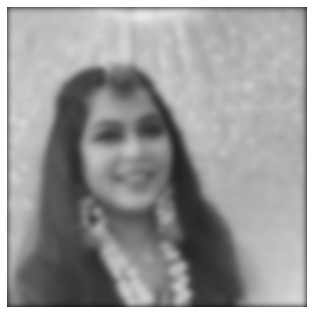

In [65]:
plot_img_orig(crop_img(img_idft_real)) 

Filtering the image without zero padding leads to a black border at the bottom, but not at the sides. To get uniform blurring, the input image can be zero padded, filtered (where the filter size has to be increased to the size of the padded image), transformed back, and then cropped. Note that in the frequency domain, the filter has to be padded as well. But if the size of the filter in the frequency domain is doubled, its cutoff frequency has to be doubled as well to get the same amount of blurring. On the other hand, the wraparound error might be acceptable (small) so that these steps can be skipped in some applications.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.6</span> Application of Lowpass Filters

Filtering in the frequency domain can be summarized as follows:
1. Compute the DFT $F(u,v)$ of the input image $f(x,y)$.
2. Shift the DFT to the center.
3. Elementwise multiplication of $F(u,v)$ by a filter (transfer) function $H(u,v)$.
4. Backshift the filter result.
5. Compute the IDFT.
6. Obtain the real part of the IDFT, which is the final result.

Padding and cropping can be implemented to avoid wraparound errors. Instead of shifting and backshifting, the functions can be multiplied by $(-1)^{(x+y)}$ before the DFT and $(-1)^{(u+v)}$ before the IDFT.

Implement / solve the following tasks:
    
1. Write a function to filter a given image with a given filter, where the image and filter have the same size.
2. Use the transfer functions for the ILPF, BLPF, and GLPF from the previous tasks to filter some images (e.g., *fruits-small.png*, which has a has a size of $200 \times 200$ pixels) and compare the results.

In [85]:
# write your code here

# filter image with given filter (image and filter must have the same size)
def filter_img(img, tf_filter):
    #img = zero_pad_img(img)
    img_dft = np.fft.fft2(img)
    glpf = tf_filter
    img_dft_shift = np.fft.fftshift(img_dft)
    img_filter = np.multiply(img_dft_shift, glpf)
    img_filter_shift = np.fft.ifftshift(img_filter)
    img_idft = np.fft.ifft2(img_filter_shift)
    img_idft_real = np.real(img_idft)
    #img_crop = crop_img(img_idft_real)
    plot_img_orig(img_idft_real)

In [88]:
ilpf1 = tf_ilpf(200, 200, 10) 
cv2.imwrite("output/ilpf1.png", 255*ilpf1)

True

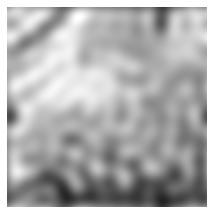

In [89]:
img = cv2.imread('images/fruits-small.png', 0)
filter_img(img, ilpf1)

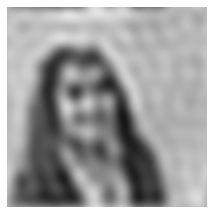

In [95]:
img = cv2.imread('images/raida200200.png', 0)
filter_img(img, ilpf1)